In [18]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

import os
from openai import OpenAI
from openai.types.fine_tuning import SupervisedMethod, SupervisedHyperparameters


from dotenv import load_dotenv  
from pprint import pprint

import constants

from prompting_utils import create_system_prompt
from model_utils import from_series_to_basemodel

import json

import model_utils
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

from pathlib import Path
import wandb
from wandb.integration.openai import autolog

# Preliminari

In [2]:
# Configurazione OpenAI
load_dotenv()
client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

# Configurazione WandB
#wandb.login(key=os.getenv("WANDB_API_KEY"))

# Parametri
base_dir = Path.cwd().parent
TEMPERATURE = 0.0
ANN_MODEL = constants.RectalCancerStagingData
SYSTEM_PROMPT_FILE_NAME = constants.SYSTEM_PROMPT_4

MODEL = constants.OPENAI_GPT_4_1

UPLOAD_DATA = True  
OVERSAMPLING = True

#Carica system prompt da file
system_prompt_path = base_dir / "data" / "prompts" / SYSTEM_PROMPT_FILE_NAME
system_prompt = create_system_prompt(system_prompt_path, ANN_MODEL)

In [3]:
print(MODEL)

gpt-4.1-2025-04-14


In [4]:
if True:
    print(system_prompt)

Sei un assistente medico radiologico esperto nella stadiazione del carcinoma rettale tramite RM.

Il tuo compito è estrarre informazioni strutturate dal referto RM fornito e restituire esclusivamente un oggetto JSON valido conforme allo schema seguente:

{"morfologia": "solido_polipoide | solido_anulare | mucinoso", "ore_inizio": "int | null", "ore_fine": "int | null", "spessore_parietale": "int | null", "estensione_cranio_caudale": "int | null", "distanza_oai": "int | null", "posizione": {"basso": "no | si", "medio": "no | si", "alto": "no | si", "giunzione": "no | si"}, "riflessione_peritoneale_anteriore": "sotto | cavallo | non_valutabile", "infiltrazione_tessuto_adiposo": "no | si_5mm | si_5mm_plus", "infiltrazione_sfinteri": "no | si", "infiltrazione_organi_extra": "no | si", "infiltrazione_organi_dettagli": {"pavimento_pelvico": "no | si", "altro": "no | si"}, "coinvolgimento_riflessione_peritoneale": "no | si", "coinvolgimento_fascia_mesorettale": "no | si", "numero_linfonodi_no

# Load Data

In [5]:
# Carichiamo i nostri file csv
file_names = {
    'train': constants.TRAIN_SPLIT_FILE_NAME,
    'validation': constants.VALIDATION_SPLIT_FILE_NAME
}

paths = {split: Path('../data/' + file_name) for split, file_name in file_names.items()}

data = dict()
for split, path in paths.items():
    data[split] = pd.read_csv(path)

train_data, validation_data = data['train'], data['validation']

################################
# Convert float columns to Int64
################################
float_cols = train_data.select_dtypes("float").columns
for col in float_cols:
    train_data[col] = train_data[col].round().astype("Int64")
    validation_data[col] = validation_data[col].round().astype("Int64")
    
# Check duplicatest
assert set(train_data.id) & set(validation_data.id) == set(), "There are overlapping IDs between test and validation sets!"

print(f"{len(train_data) = }")
print(f"{len(validation_data) = }")

len(train_data) = 184
len(validation_data) = 66


# Oversampling

In [6]:
def rarity_scores(df, categorical_cols, use_lof=True):
    # 1) Frequency encoding
    freq_df = df.copy()
    for col in categorical_cols:
        freqs = df[col].value_counts(normalize=True)
        freq_df[col] = df[col].map(freqs)
    
    # 2) Rarità statistica (sorpresa)
    rarity = -np.log(freq_df[categorical_cols]).sum(axis=1)
    
    result = df.copy()
    result["rarity_stat"] = rarity
    
    # 3) LOF opzionale
    if use_lof:
        lof = LocalOutlierFactor(n_neighbors=10, metric="euclidean")
        lof_scores = -lof.fit_predict(freq_df[categorical_cols])
        lof_factor = -lof.negative_outlier_factor_
        result["lof_flag"] = lof_scores
        result["rarity_lof"] = lof_factor
    
    return result


def rarity_with_numeric(df, categorical_cols, numeric_cols):
    df = df.copy()

    # --- 1) CATEGORICAL: frequenze e sorpresa informativa ---
    freq_maps = {col: df[col].value_counts(normalize=True) for col in categorical_cols}

    freq_matrix = pd.DataFrame({
        col: df[col].map(freq_maps[col]) for col in categorical_cols
    })

    rarity_cat = -np.log(freq_matrix).sum(axis=1)

    # --- 2) NUMERIC: Z-score solo sui valori presenti ---
    scaler = StandardScaler()
    scaler.fit(df[numeric_cols])

    Z = pd.DataFrame(scaler.transform(df[numeric_cols]),
                     columns=numeric_cols, index=df.index)

    # Dove il valore originale è NaN → contributo 0
    Z = Z.where(~df[numeric_cols].isna(), 0)

    rarity_num = np.abs(Z).sum(axis=1)

    # --- 3) Normalizzazione robusta ---
    def safe_minmax(x):
        rng = x.max() - x.min()
        return (x - x.min()) / rng if rng != 0 else np.zeros_like(x)

    rarity_cat_norm = safe_minmax(rarity_cat)
    rarity_num_norm = safe_minmax(rarity_num)

    # --- 4) Combinazione ---
    rarity_total = rarity_cat_norm + rarity_num_norm

    df["rarity_cat"] = rarity_cat_norm
    df["rarity_num"] = rarity_num_norm
    df["rarity_total"] = rarity_total

    return df, scaler


In [7]:
train_data.head()

,id,report_text,profile,morfologia,ore_inizio,ore_fine,spessore_parietale,estensione_cranio_caudale,distanza_oai,posizione,...,posizione_alto,posizione_giunzione,infiltrazione_organi_dettagli_pavimento_pelvico,infiltrazione_organi_dettagli_altro,sedi_linfonodi_mesorettali,sedi_linfonodi_rettali_superiori,sedi_linfonodi_otturatori,sedi_linfonodi_iliaci,sedi_linfonodi_altro,split
0,46,"NEL RETTO MEDIO, A CIRCA 7 CM DAL MARGINE ANAL...",GuidoImbemba,solido_polipoide,<NA>,<NA>,<NA>,45,25,['medio'],...,no,no,si,no,si,si,si,no,si,train
1,47,SI DOCUMENTA UN ISPESSIMENTO FOCALE DELLA PARE...,GuidoImbemba,solido_polipoide,<NA>,<NA>,<NA>,52,<NA>,['medio'],...,no,no,no,no,no,no,no,no,no,train
2,51,SI CONFERMA LA PRESENZA IN CORRISPONDENZA DEL ...,GuidoImbemba,solido_anulare,12,12,<NA>,100,70,"['giunzione', 'alto']",...,si,si,no,no,si,si,no,no,no,train
3,54,"ESAME ESEGUITO MEDIANTE SEQUENZE FSE, DWI E VI...",PietroPaoloAzzaro,solido_anulare,6,12,<NA>,30,80,['medio'],...,no,no,no,no,si,no,si,si,no,train
4,57,RM ADDOME INFERIORE (S/C MDC)\nTECNICA\nESAME ...,PietroPaoloAzzaro,solido_polipoide,3,12,19,49,<NA>,['basso'],...,no,no,no,no,si,si,si,si,no,train


,id,report_text,profile,morfologia,ore_inizio,ore_fine,spessore_parietale,estensione_cranio_caudale,distanza_oai,posizione,...,infiltrazione_organi_dettagli_altro,sedi_linfonodi_mesorettali,sedi_linfonodi_rettali_superiori,sedi_linfonodi_otturatori,sedi_linfonodi_iliaci,sedi_linfonodi_altro,split,rarity_cat,rarity_num,rarity_total
0,46,"NEL RETTO MEDIO, A CIRCA 7 CM DAL MARGINE ANAL...",GuidoImbemba,solido_polipoide,<NA>,<NA>,<NA>,45,25,['medio'],...,no,si,si,si,no,si,train,0.708253,0.138029,0.846283
1,47,SI DOCUMENTA UN ISPESSIMENTO FOCALE DELLA PARE...,GuidoImbemba,solido_polipoide,<NA>,<NA>,<NA>,52,<NA>,['medio'],...,no,no,no,no,no,no,train,0.531328,0.019913,0.551241
2,51,SI CONFERMA LA PRESENZA IN CORRISPONDENZA DEL ...,GuidoImbemba,solido_anulare,12,12,<NA>,100,70,"['giunzione', 'alto']",...,no,si,si,no,no,no,train,0.806064,0.849075,1.655139
3,54,"ESAME ESEGUITO MEDIANTE SEQUENZE FSE, DWI E VI...",PietroPaoloAzzaro,solido_anulare,6,12,<NA>,30,80,['medio'],...,no,si,no,si,si,no,train,0.861791,0.577074,1.438865
4,57,RM ADDOME INFERIORE (S/C MDC)\nTECNICA\nESAME ...,PietroPaoloAzzaro,solido_polipoide,3,12,19,49,<NA>,['basso'],...,no,si,si,si,si,no,train,0.826278,1.000000,1.826278


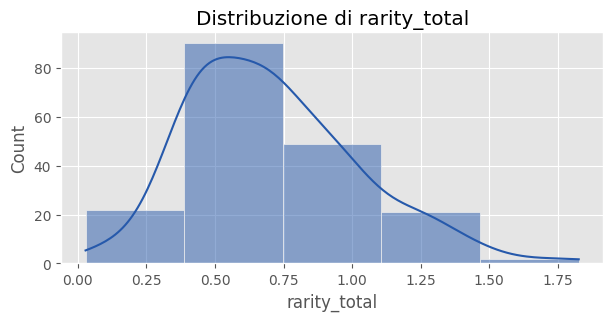

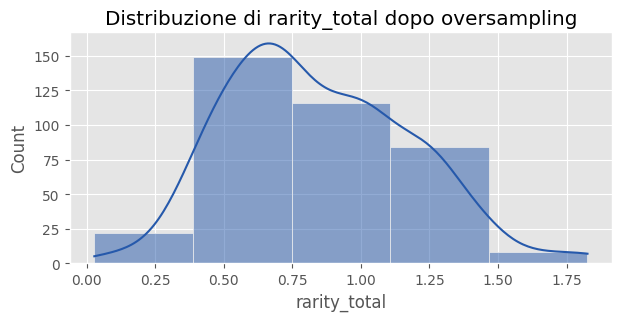

In [8]:
if OVERSAMPLING:
    numeric_cols = model_utils.get_regression_fields(ANN_MODEL)
    categorical_cols = [f for f in ANN_MODEL.model_fields if f not in numeric_cols]

    train_data, _ = rarity_with_numeric(train_data, categorical_cols, numeric_cols)
    
    display(train_data.head())
    
    plt.figure(figsize=(7, 3))
    sns.histplot(train_data["rarity_total"], kde=True, color="#2659ab", bins=5)
    plt.xlabel("rarity_total")
    plt.title("Distribuzione di rarity_total")
    plt.show()
    
    chunk_1 = train_data[(train_data.rarity_total < 0.5)]
    chunk_2 = train_data[(train_data.rarity_total.between(0.5, 1.0, inclusive='left'))]
    chunk_3 = train_data[(train_data.rarity_total >= 1)]
    
    data_train_oversampled = pd.concat([chunk_1] + 2*[chunk_2] + 4*[chunk_3], ignore_index=True)
    data_train_oversampled = data_train_oversampled.sample(frac=1, random_state=constants.SEED).reset_index(drop=True)
    
    plt.figure(figsize=(7, 3))
    sns.histplot(data_train_oversampled["rarity_total"], bins=5, kde=True, color="#2659ab")
    plt.xlabel("rarity_total")
    plt.title("Distribuzione di rarity_total dopo oversampling")
    plt.show()

# Upload data to Openai dashboard

## Create local fine-tuning datasets

Il dataset jsonl dovrà contenere righe con il formato chat completetion. Ogni riga dovrà essere:

```
{
  "messages": [
    { "role": "system", "content": <system_prompt>}
    { "role": "user", "content": <report_text> },
    { "role": "assistant", "content": <correct_annotation> },
  ]
}
```

In [9]:
def prepare_example_conversation(row):
    return {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": row['report_text']},
            {"role": "assistant", "content": from_series_to_basemodel(row, ANN_MODEL).model_dump_json()},
        ]
    }
    
def write_jsonl(data_list: list, filename: str) -> None:
    with open(filename, "w") as out:
        for ddict in data_list:
            jout = json.dumps(ddict) + "\n"
            out.write(jout)
            
def upload_file(file_name: str, purpose: str) -> str:
    with open(file_name, "rb") as file_fd:
        response = client.files.create(file=file_fd, purpose=purpose)
    return response.id

In [10]:
if UPLOAD_DATA:
    validation_list = validation_data.apply(prepare_example_conversation, axis=1).tolist()
    
    if OVERSAMPLING:
        train_list = data_train_oversampled.apply(prepare_example_conversation, axis=1).tolist()
        training_file_path = base_dir / 'data' / 'ft-dataset' / constants.OPENAI_TRAIN_OVERSAMPLING_FILE_NAME
        write_jsonl(train_list, training_file_path)
    else:
        train_list = train_data.apply(prepare_example_conversation, axis=1).tolist()
        training_file_path = base_dir / 'data' / 'ft-dataset' / constants.OPENAI_TRAIN_FILE_NAME
        write_jsonl(train_list, training_file_path)

    validation_file_path = base_dir / 'data' / 'ft-dataset' / constants.OPENAI_VALIDATION_FILE_NAME
    write_jsonl(validation_list, validation_file_path)
    
    training_file_id = upload_file(training_file_path, "fine-tune")
    validation_file_id = upload_file(validation_file_path, "fine-tune")

    print("Training file ID:", training_file_id)
    print("Validation file ID:", validation_file_id)

Training file ID: file-BWcYGiQu3GqZ2BbuLw1C7J
Validation file ID: file-5KzogbRS4cvhTGwHkg1v1G


# Fine tuning

In [11]:
print(MODEL)

gpt-4.1-2025-04-14


In [20]:
fine_tuning_job = client.fine_tuning.jobs.create(
  training_file=training_file_id,
  validation_file=validation_file_id,
  model=MODEL,
  seed=constants.SEED,
  suffix="report-extractor",
  method={
    "type": "supervised",
    "supervised": SupervisedMethod(
      hyperparameters=SupervisedHyperparameters(
        n_epochs=1)
    )
  },
  integrations=[
    {
      "type": "wandb",
      "wandb": {"project": "PRIN"}
    }
  ]
)

job_id = fine_tuning_job.id

In [21]:
print("Job ID:", fine_tuning_job.id)
print("Status:", fine_tuning_job.status)

Job ID: ftjob-Cljd4zB9yl0FHCJgwtoBMq4g
Status: validating_files


In [22]:
response = client.fine_tuning.jobs.retrieve(job_id)

print("Job ID:", response.id)
print("Status:", response.status)
print("Trained Tokens:", response.trained_tokens)

Job ID: ftjob-Cljd4zB9yl0FHCJgwtoBMq4g
Status: validating_files
Trained Tokens: None


In [25]:
response = client.fine_tuning.jobs.list_events(job_id)

events = response.data
events.reverse()

for event in events:
    print(event.message)

Step 270/379: training loss=0.01, validation loss=0.01
Step 271/379: training loss=0.00
Step 272/379: training loss=0.01
Step 273/379: training loss=0.05
Step 274/379: training loss=0.02
Step 275/379: training loss=0.01
Step 276/379: training loss=0.04
Step 277/379: training loss=0.00
Step 278/379: training loss=0.01
Step 279/379: training loss=0.00
Step 280/379: training loss=0.06, validation loss=0.01
Step 281/379: training loss=0.00
Step 282/379: training loss=0.00
Step 283/379: training loss=0.02
Step 284/379: training loss=0.01
Step 285/379: training loss=0.01
Step 286/379: training loss=0.01
Step 287/379: training loss=0.05
Step 288/379: training loss=0.03
Step 289/379: training loss=0.02


In [26]:
response = client.fine_tuning.jobs.retrieve(job_id)
fine_tuned_model_id = response.fine_tuned_model

if fine_tuned_model_id is None:
    raise RuntimeError(
        "Fine-tuned model ID not found. Your job has likely not been completed yet."
    )

print("Fine-tuned model ID:", fine_tuned_model_id)

Fine-tuned model ID: ft:gpt-4.1-2025-04-14:luca-tramonti:report-extractor:D8nTVX9B
